<a href="https://colab.research.google.com/github/tomasricardo1999/python-showcase/blob/main/World-Bank-Data-Analysis/World_Population_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World Population Analysis

🌍 **Project Objectives — Population Indicators via API & Python**


🚀 Demonstrate Practical API Skills
* Show how Python can interact with real external APIs (World Bank Indicators API) to retrieve population data used in official country dashboards, such as the “Population, total” values.  

🌐 Collect Multiple Demographic Indicators

* Work with gender, age‑structure, and urbanization metrics included in the World Development Indicators “People” theme, which covers population composition and related demographic data.  

🗂 Process & Store Data Effectively

* Use pandas to clean API responses, structure them into tables, and prepare datasets ready for analysis.

📊 Create Clear Visualizations

* Build visual comparisons and trend analyses across different population indicators and countries.

🧠 Turn Data Into Insights

* Translate raw population numbers into meaningful observations about demographic and social evolution.

# Import Python Libraries

In [110]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get ISO-3 Codes from All World Countries

In [22]:
def get_real_countries():
    url = "https://api.worldbank.org/v2/country?format=json&per_page=400"
    r = requests.get(url)
    data = r.json()
    records = data[1]

    countries = [c["id"] for c in records if c["region"]["id"] != "NA"]
    return sorted(countries)

real_countries = get_real_countries()

print(f"\nTotal real countries: {len(real_countries)}")
print("Countries (ISO‑3 codes):\n")

row_size = 20  # number of codes per row

for i in range(0, len(real_countries), row_size):
    chunk = real_countries[i:i + row_size]
    print(" | ".join(chunk))



Total real countries: 217
Countries (ISO‑3 codes):

ABW | AFG | AGO | ALB | AND | ARE | ARG | ARM | ASM | ATG | AUS | AUT | AZE | BDI | BEL | BEN | BFA | BGD | BGR | BHR
BHS | BIH | BLR | BLZ | BMU | BOL | BRA | BRB | BRN | BTN | BWA | CAF | CAN | CHE | CHI | CHL | CHN | CIV | CMR | COD
COG | COL | COM | CPV | CRI | CUB | CUW | CYM | CYP | CZE | DEU | DJI | DMA | DNK | DOM | DZA | ECU | EGY | ERI | ESP
EST | ETH | FIN | FJI | FRA | FRO | FSM | GAB | GBR | GEO | GHA | GIB | GIN | GMB | GNB | GNQ | GRC | GRD | GRL | GTM
GUM | GUY | HKG | HND | HRV | HTI | HUN | IDN | IMN | IND | IRL | IRN | IRQ | ISL | ISR | ITA | JAM | JOR | JPN | KAZ
KEN | KGZ | KHM | KIR | KNA | KOR | KWT | LAO | LBN | LBR | LBY | LCA | LIE | LKA | LSO | LTU | LUX | LVA | MAC | MAF
MAR | MCO | MDA | MDG | MDV | MEX | MHL | MKD | MLI | MLT | MMR | MNE | MNG | MNP | MOZ | MRT | MUS | MWI | MYS | NAM
NCL | NER | NGA | NIC | NLD | NOR | NPL | NRU | NZL | OMN | PAK | PAN | PER | PHL | PLW | PNG | POL | PRI | PRK | PRT
PRY

# Create function to get worldbank timeseries for Countries

In [39]:
def get_worldbank_timeseries(indicator,
                             countries = real_countries):

    base_url = "https://api.worldbank.org/v2/country/{countries}/indicator/{indicator}"
    country_str = ";".join(countries)

    url = base_url.format(countries=country_str, indicator=indicator)
    params = {"format": "json", "per_page": 20000}

    # Request data
    r = requests.get(url, params=params)
    r.raise_for_status()

    data = r.json()
    records = data[-1]  # last element contains observations

    # Normalize JSON into DataFrame
    df = pd.json_normalize(records)

    # Keep relevant fields: date, value, and country code
    df = df[["date", "countryiso3code", "value"]]

    # Pivot to time series format
    df = df.pivot_table(values="value",
                        index="date",
                        columns="countryiso3code")

    # Sort by year ascending and convert index to int
    df.index = df.index.astype(int)
    df = df.sort_index()

    return df


# Get_worldbank_timeseries Data Retrieval

In [86]:
SP_POP_TOTL = get_worldbank_timeseries("SP.POP.TOTL")
SP_POP_TOTL_MA_IN = get_worldbank_timeseries("SP.POP.TOTL.MA.IN")
SP_POP_TOTL_FE_IN = get_worldbank_timeseries("SP.POP.TOTL.FE.IN")
SP_POP_0014_TO  = get_worldbank_timeseries("SP.POP.0014.TO")
SP_POP_1564_TO  = get_worldbank_timeseries("SP.POP.1564.TO")
SP_POP_65UP_TO = get_worldbank_timeseries("SP.POP.65UP.TO")
SP_URB_TOTL = get_worldbank_timeseries("SP.URB.TOTL")
SP_RUR_TOTL = get_worldbank_timeseries("SP.RUR.TOTL")
SM_POP_NETM = get_worldbank_timeseries("SM.POP.NETM")

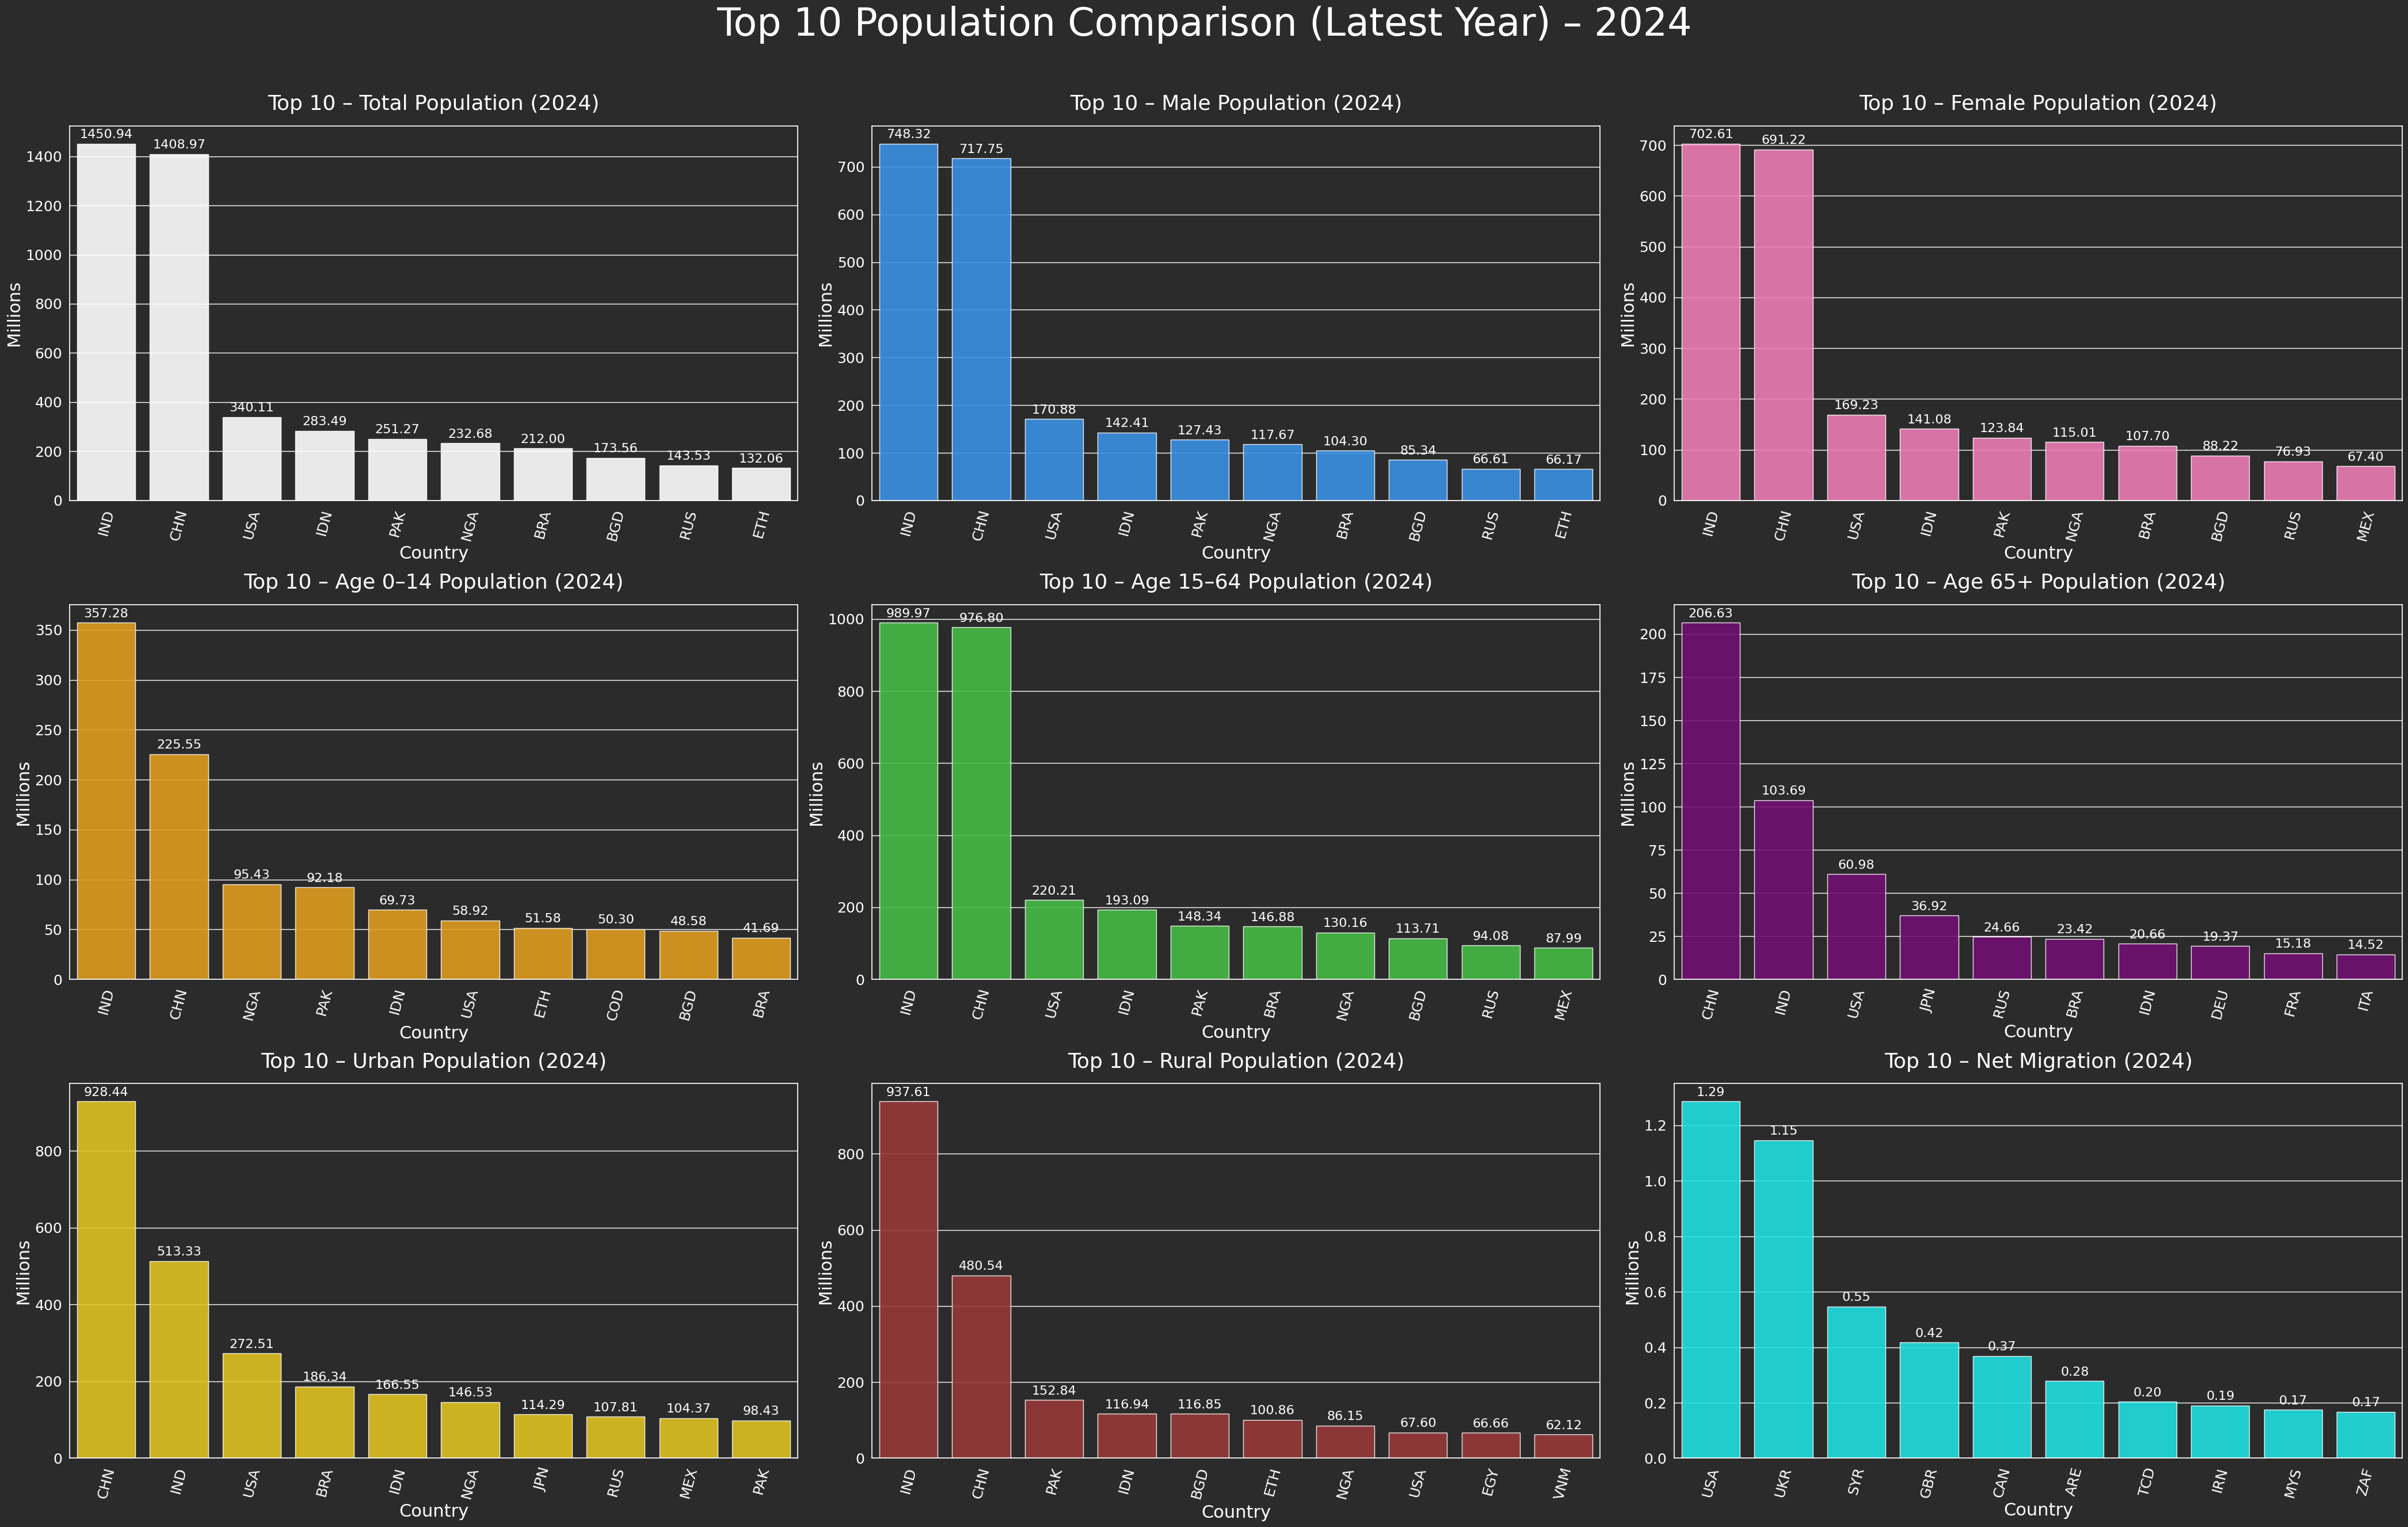

In [113]:
# ---------------------------
#      9‑GRAPH DASHBOARD
# ---------------------------
def plot_top10_population_full(
    df_total, df_male, df_female,
    df_0_14, df_15_64, df_65_up,
    df_urban, df_rural, df_migration,
    main_title="Top 10 Population Comparison (Latest Year)"
):

    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme(style="darkgrid")

    # Detect latest year across all datasets
    latest_year = int(max(
        df_total.index.max(),
        df_male.index.max(),
        df_female.index.max(),
        df_0_14.index.max(),
        df_15_64.index.max(),
        df_65_up.index.max(),
        df_urban.index.max(),
        df_rural.index.max(),
        df_migration.index.max()
    ))

    # Helper: get Top 10 (millions)
    def top10(df):
        return (df.loc[latest_year] / 1_000_000).sort_values(ascending=False).head(10)

    top10_total     = top10(df_total)
    top10_male      = top10(df_male)
    top10_female    = top10(df_female)
    top10_0_14      = top10(df_0_14)
    top10_15_64     = top10(df_15_64)
    top10_65_up     = top10(df_65_up)
    top10_urban     = top10(df_urban)
    top10_rural     = top10(df_rural)
    top10_migration = (df_migration.loc[latest_year] / 1_000_000).sort_values(ascending=False).head(10)

    # Create 3×3 plot grid
    fig, axes = plt.subplots(3, 3, figsize=(42, 26))
    axes = axes.flatten()

    # Grey background
    fig.patch.set_facecolor("#2b2b2b")
    for ax in axes:
        ax.set_facecolor("#2b2b2b")

    # Helper: Bar plot
    def plot_bar(ax, series, title, color):
        bars = sns.barplot(
            x=series.index,
            y=series.values,
            ax=ax,
            color=color,
            edgecolor="white",
            alpha=0.90
        )

        # Bigger subplot titles
        ax.set_title(f"{title} ({latest_year})", fontsize=26, color="white", pad=20)

        # Bigger axis labels
        ax.set_xlabel("Country", fontsize=22, color="white")
        ax.set_ylabel("Millions", fontsize=22, color="white")

        # Bigger tick labels (X & Y)
        ax.tick_params(axis='x', rotation=75, colors="white", labelsize=18)
        ax.tick_params(axis='y', colors="white", labelsize=18)

        # Show value labels above bars (two decimals)
        ax.bar_label(ax.containers[0], fmt="%.2f", color="white", fontsize=16, padding=4)

        # White borders
        for spine in ax.spines.values():
            spine.set_color("white")

    # Draw all 9 charts
    plot_bar(axes[0], top10_total,     "Top 10 – Total Population",         "white")
    plot_bar(axes[1], top10_male,      "Top 10 – Male Population",          "dodgerblue")
    plot_bar(axes[2], top10_female,    "Top 10 – Female Population",        "hotpink")

    plot_bar(axes[3], top10_0_14,      "Top 10 – Age 0–14 Population",      "orange")
    plot_bar(axes[4], top10_15_64,     "Top 10 – Age 15–64 Population",     "limegreen")
    plot_bar(axes[5], top10_65_up,     "Top 10 – Age 65+ Population",       "purple")

    plot_bar(axes[6], top10_urban,     "Top 10 – Urban Population",         "gold")
    plot_bar(axes[7], top10_rural,     "Top 10 – Rural Population",         "brown")
    plot_bar(axes[8], top10_migration, "Top 10 – Net Migration",            "cyan")

    # Bigger main title + more separation
    fig.suptitle(
        f"{main_title} – {latest_year}",
        fontsize=48, color="white", y=1.02
    )

    plt.tight_layout()
    plt.show()


# ---------------------------
#        RUN DASHBOARD
# ---------------------------
plot_top10_population_full(
    SP_POP_TOTL,
    SP_POP_TOTL_MA_IN,
    SP_POP_TOTL_FE_IN,
    SP_POP_0014_TO,
    SP_POP_1564_TO,
    SP_POP_65UP_TO,
    SP_URB_TOTL,
    SP_RUR_TOTL,
    SM_POP_NETM
)

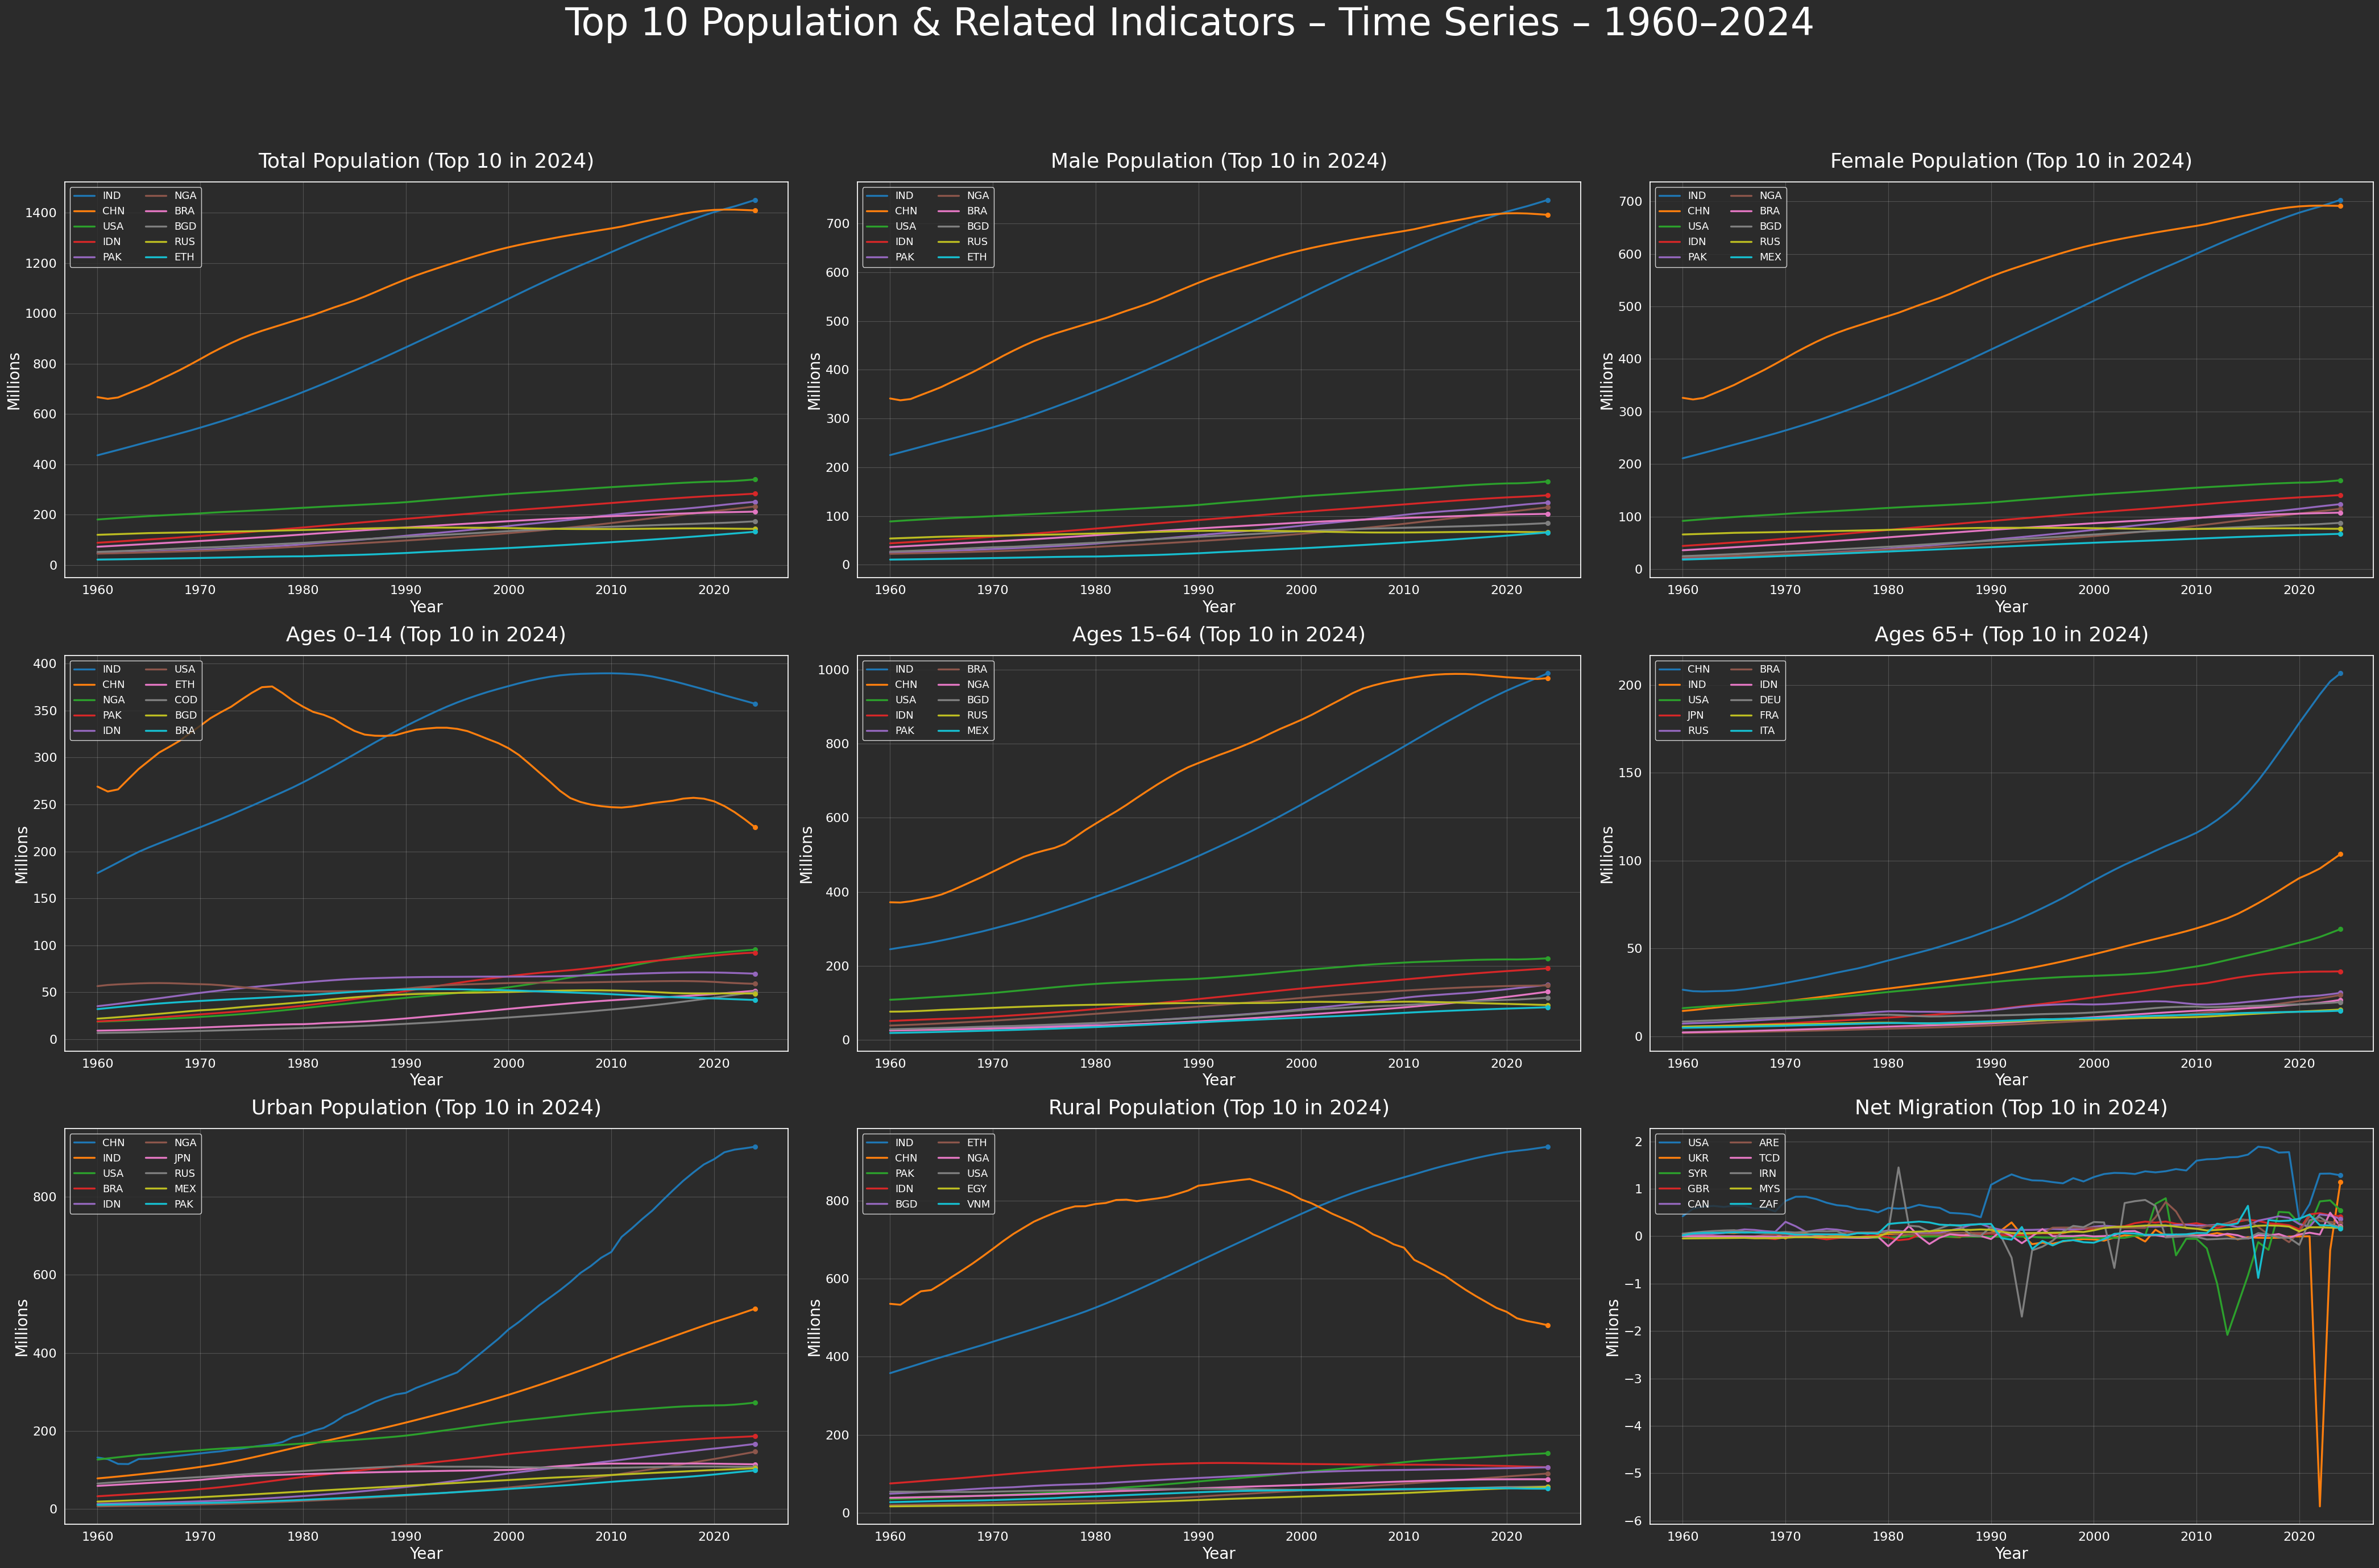

In [112]:
# ===========================
#   9× Time Series Dashboard
# ===========================
def plot_timeseries_population_full(
    df_total, df_male, df_female,
    df_0_14, df_15_64, df_65_up,
    df_urban, df_rural, df_migration,
    main_title="Top 10 Population & Related Indicators – Time Series"
):
    """
    Plots a 3×3 grid of TIME SERIES charts:
      1) Total population
      2) Male population
      3) Female population
      4) Ages 0–14
      5) Ages 15–64
      6) Ages 65+
      7) Urban population
      8) Rural population
      9) Net migration

    Logic:
      - For each panel, select Top 10 countries by the indicator's LATEST year (non-null values).
      - Plot full time series for those Top 10 countries.
      - Scale values to millions (including Net Migration for consistency).
    """

    # ------ Theme ------
    sns.set_theme(style="darkgrid")
    face = "#2b2b2b"
    textc = "white"

    # ------ Ensure numeric, sorted year index in ALL dfs ------
    def clean_df(df):
        df = df.copy()
        if not np.issubdtype(df.index.dtype, np.number):
            df.index = pd.to_numeric(df.index, errors="coerce")
        df = df.sort_index()
        # Drop completely empty rows (if any)
        return df[~df.index.isna()]

    dfs = [
        df_total, df_male, df_female,
        df_0_14, df_15_64, df_65_up,
        df_urban, df_rural, df_migration
    ]
    df_total, df_male, df_female, df_0_14, df_15_64, df_65_up, df_urban, df_rural, df_migration = [clean_df(d) for d in dfs]

    # ------ Titles & colors ------
    titles = [
        "Total Population",
        "Male Population",
        "Female Population",
        "Ages 0–14",
        "Ages 15–64",
        "Ages 65+",
        "Urban Population",
        "Rural Population",
        "Net Migration",
    ]
    # Base colors per panel (line colors will cycle within)
    panel_colors = [
        "white", "dodgerblue", "hotpink",
        "orange", "limegreen", "purple",
        "gold", "sienna", "cyan"
    ]

    panels = [
        df_total, df_male, df_female,
        df_0_14, df_15_64, df_65_up,
        df_urban, df_rural, df_migration
    ]

    # Determine an overall year range to display in the suptitle
    year_min = int(np.nanmin([d.index.min() for d in panels]))
    year_max = int(np.nanmax([d.index.max() for d in panels]))

    # ------ Build 3×3 figure ------
    fig, axes = plt.subplots(3, 3, figsize=(42, 26))
    axes = axes.flatten()
    fig.patch.set_facecolor(face)
    for ax in axes:
        ax.set_facecolor(face)

    # ------ Plot helper: time series for Top 10 by latest year ------
    def plot_ts(ax, df, panel_title, panel_color):
        # Latest year with any data
        latest_year = int(df.index.max())

        # Pick Top 10 countries by latest year values (non-null)
        latest_vals = df.loc[latest_year].dropna()
        if latest_vals.empty:
            ax.set_title(f"{panel_title} (No data)", fontsize=24, color=textc, pad=18)
            ax.set_xlabel("Year", fontsize=18, color=textc)
            ax.set_ylabel("Millions", fontsize=18, color=textc)
            ax.tick_params(axis='x', colors=textc, labelsize=14)
            ax.tick_params(axis='y', colors=textc, labelsize=14)
            for spine in ax.spines.values():
                spine.set_color(textc)
            return

        top_countries = latest_vals.sort_values(ascending=False).head(10).index.tolist()

        # Scale to millions for plotting
        df_mil = df[top_countries] / 1_000_000

        # Plot lines
        palette = sns.color_palette("tab10", n_colors=len(top_countries))
        for i, iso in enumerate(top_countries):
            y = df_mil[iso]
            ax.plot(df_mil.index, y, color=palette[i], linewidth=2.4, solid_capstyle="round", label=iso)
            # Mark last available point for the line
            last_valid_idx = y.last_valid_index()
            if pd.notna(last_valid_idx):
                ax.scatter([last_valid_idx], [y.loc[last_valid_idx]], color=palette[i], s=30, zorder=3)

        # Titles / labels / ticks
        ax.set_title(f"{panel_title} (Top 10 in {latest_year})", fontsize=26, color=textc, pad=18)
        ax.set_xlabel("Year", fontsize=20, color=textc)
        ax.set_ylabel("Millions", fontsize=20, color=textc)

        ax.tick_params(axis='x', colors=textc, labelsize=16)
        ax.tick_params(axis='y', colors=textc, labelsize=16)

        # Light grid, white spines
        ax.grid(True, color="white", alpha=0.18, linewidth=0.8)
        for spine in ax.spines.values():
            spine.set_color(textc)

        # Legend (inside, semi-transparent box)
        leg = ax.legend(
            loc="upper left", fontsize=13, ncol=2,
            frameon=True, facecolor=face, edgecolor="white"
        )
        for txt in leg.get_texts():
            txt.set_color("white")

    # ------ Draw each panel ------
    for idx, (ax, dfp, ttl, color) in enumerate(zip(axes, panels, titles, panel_colors)):
        plot_ts(ax, dfp, ttl, color)

    # ------ Main title (bigger and spaced up) ------
    fig.suptitle(
        f"{main_title} – {year_min}–{year_max}",
        fontsize=48, color="white", y=1.06
    )

    plt.tight_layout()
    plt.show()


# ===========================
#         RUN IT
# ===========================
plot_timeseries_population_full(
    SP_POP_TOTL,
    SP_POP_TOTL_MA_IN,
    SP_POP_TOTL_FE_IN,
    SP_POP_0014_TO,
    SP_POP_1564_TO,
    SP_POP_65UP_TO,
    SP_URB_TOTL,
    SP_RUR_TOTL,
    SM_POP_NETM
)

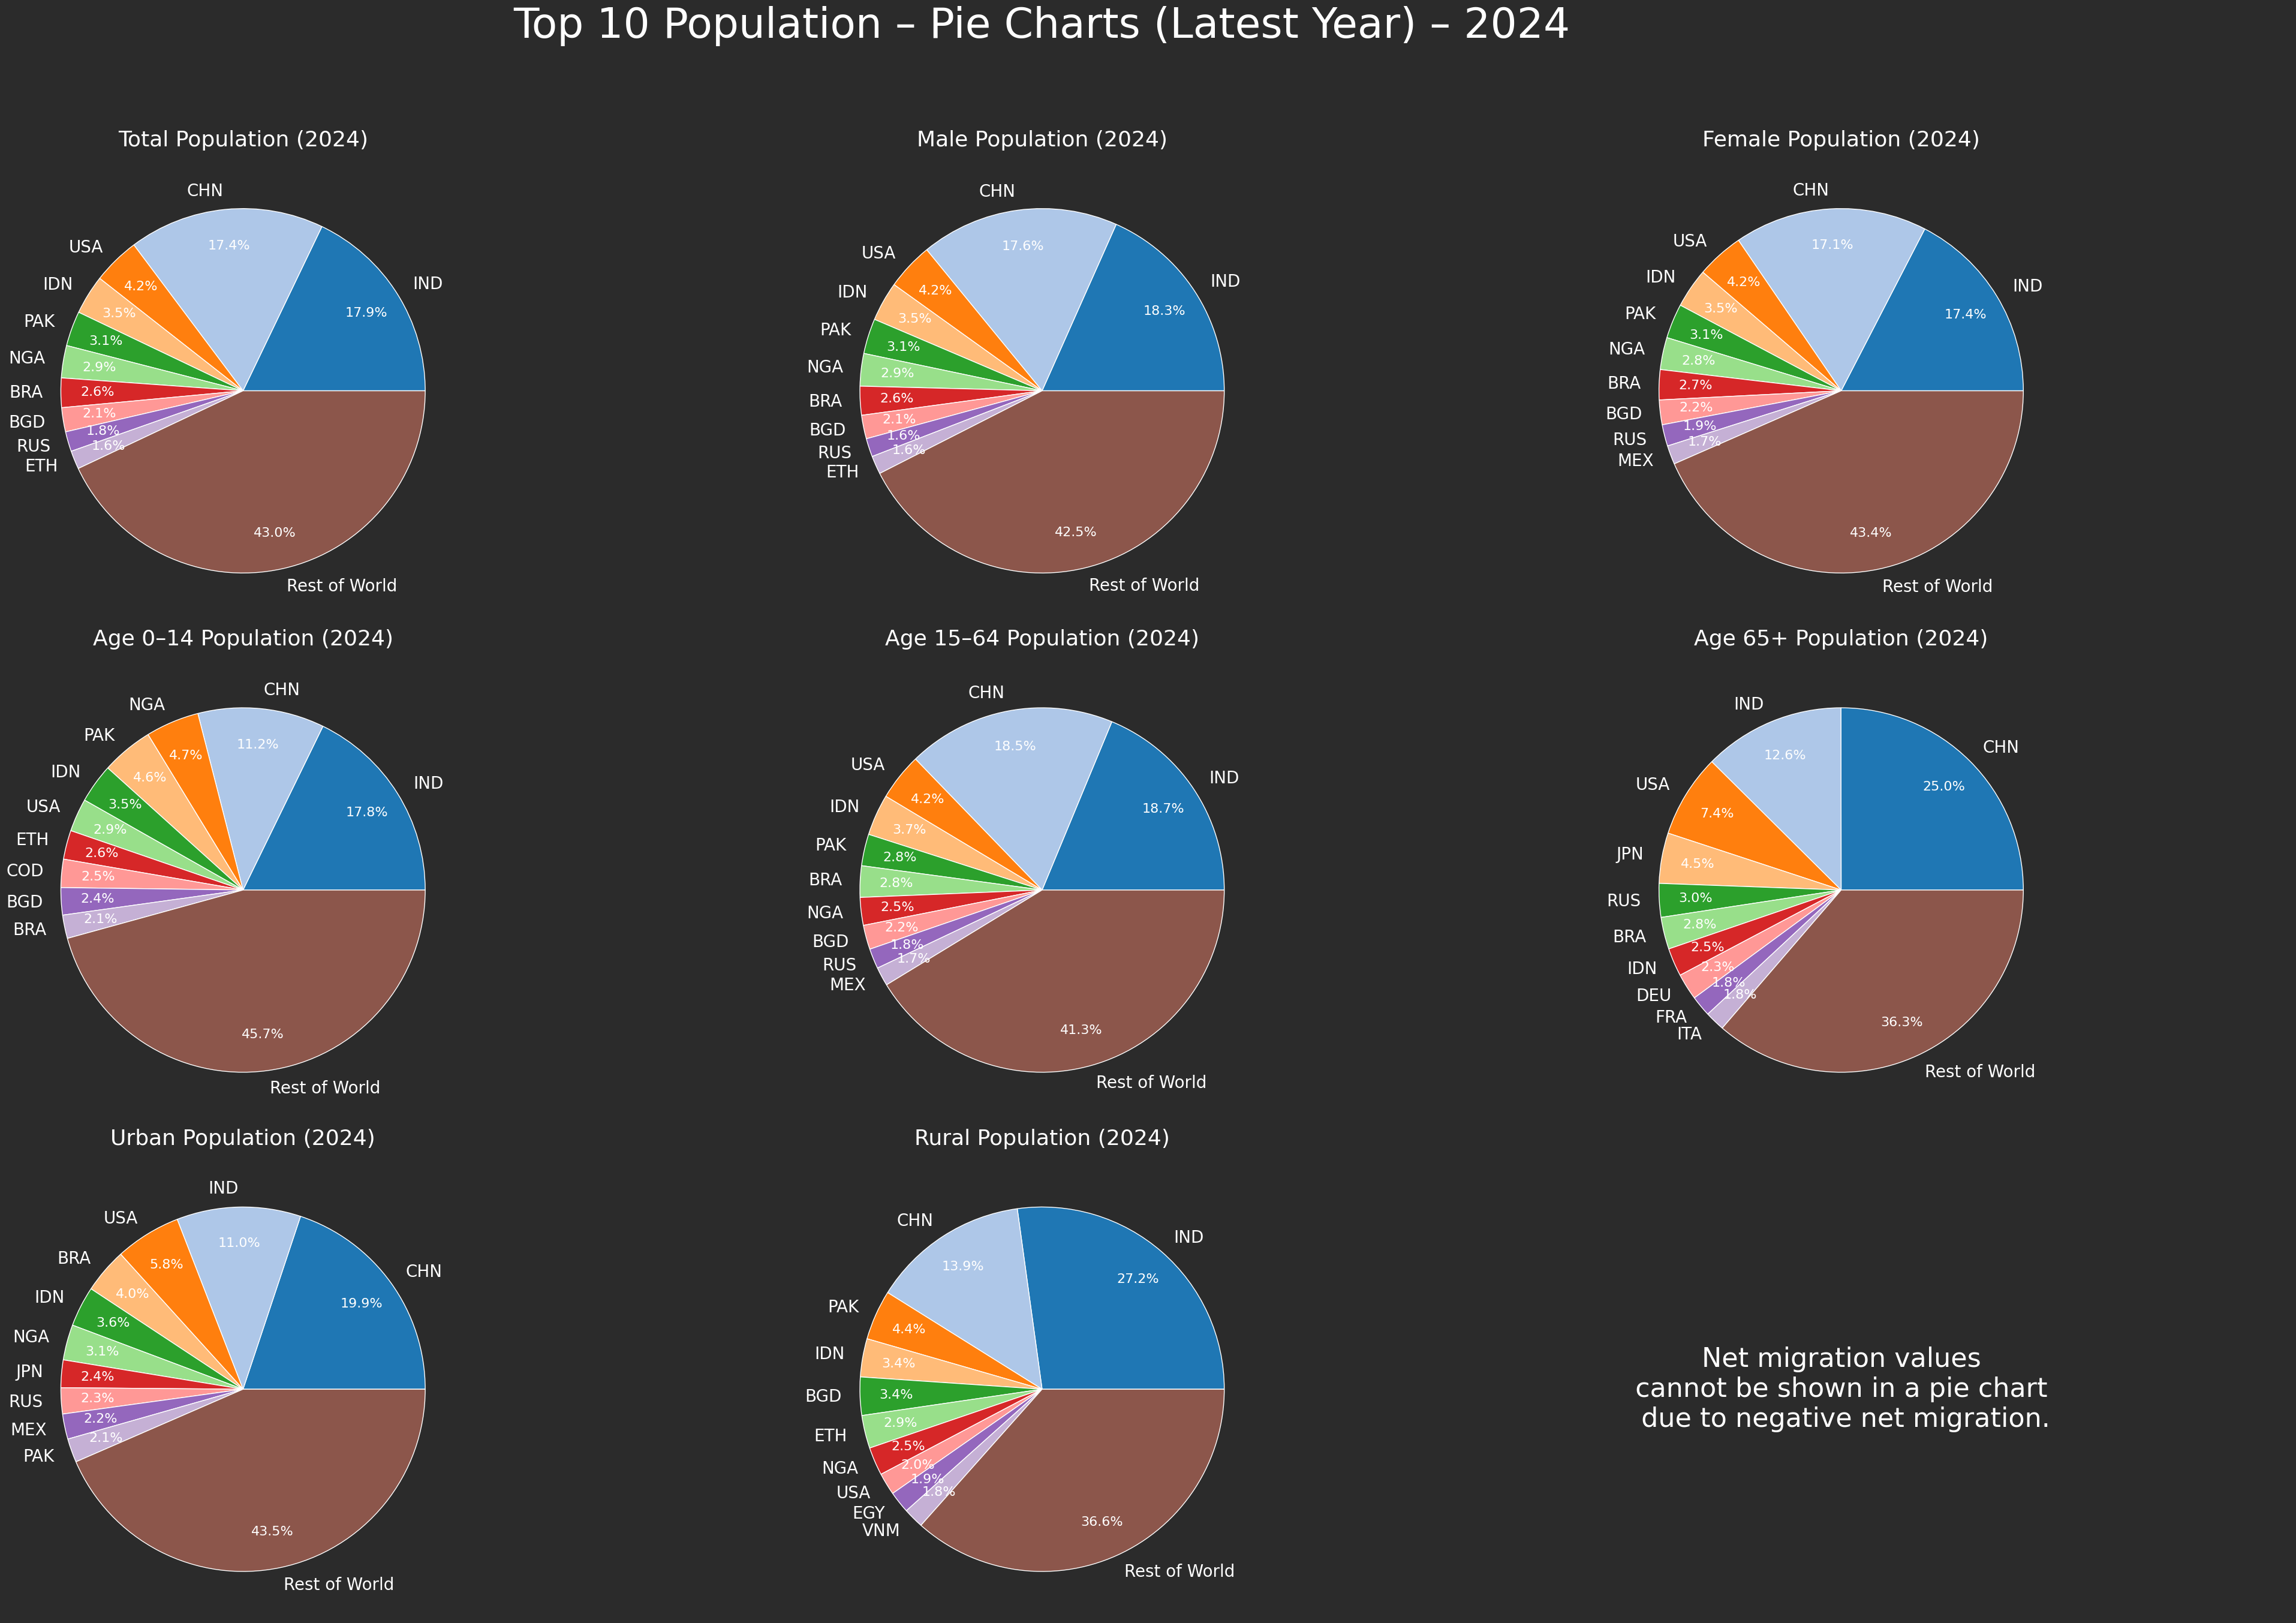

In [121]:
# ------------------------------------------
#        8× PIE + 1 TEXT PANEL DASHBOARD
# ------------------------------------------
def plot_top10_pie_full(
    df_total, df_male, df_female,
    df_0_14, df_15_64, df_65_up,
    df_urban, df_rural, df_migration,
    main_title="Top 10 Population – Pie Charts (Latest Year)"
):

    sns.set_theme(style="darkgrid")
    face = "#2b2b2b"
    textc = "white"

    # Detect latest year across all datasets except migration (not plotted)
    latest_year = int(max(
        df_total.index.max(),
        df_male.index.max(),
        df_female.index.max(),
        df_0_14.index.max(),
        df_15_64.index.max(),
        df_65_up.index.max(),
        df_urban.index.max(),
        df_rural.index.max()
    ))

    # Helper: top10 + rest (millions)
    def get_pie_values(df):
        series = (df.loc[latest_year] / 1_000_000).dropna()
        series_sorted = series.sort_values(ascending=False)
        top10 = series_sorted.head(10)
        rest = series_sorted.iloc[10:].sum()
        labels = top10.index.tolist() + ["Rest of World"]
        values = top10.values.tolist() + [rest]
        return labels, values

    # PIE PANELS (8 of them)
    pies = [
        (df_total, "Total Population"),
        (df_male, "Male Population"),
        (df_female, "Female Population"),
        (df_0_14, "Age 0–14 Population"),
        (df_15_64, "Age 15–64 Population"),
        (df_65_up, "Age 65+ Population"),
        (df_urban, "Urban Population"),
        (df_rural, "Rural Population"),
        # SLOT 9 = TEXT PANEL INSTEAD OF PIE
    ]

    # Create 3×3 grid
    fig, axes = plt.subplots(3, 3, figsize=(42, 26))
    fig.patch.set_facecolor(face)
    axes = axes.flatten()

    base_colors = sns.color_palette("tab20", 20)

    # ---- Draw the 8 pies ----
    for ax, (dfp, title) in zip(axes[:8], pies):
        ax.set_facecolor(face)

        labels, values = get_pie_values(dfp)

        wedges, texts, autotexts = ax.pie(
            values,
            labels=labels,
            autopct="%.1f%%",
            pctdistance=0.80,
            textprops=dict(color=textc, fontsize=20),
            colors=base_colors[:len(values)],
            wedgeprops={"linewidth": 1, "edgecolor": "white"}
        )

        ax.set_title(f"{title} ({latest_year})", fontsize=26, color=textc, pad=20)

        for t in autotexts:
            t.set_color("white")
            t.set_fontsize(16)

    # ---- PANEL 9: TEXT BOX INSTEAD OF PIE ----
    ax_text = axes[8]
    ax_text.set_facecolor(face)
    ax_text.axis("off")

    ax_text.text(
        0.5, 0.5,
        "Net migration values\n cannot be shown in a pie chart \n due to negative net migration.",
        color="white",
        fontsize=32,
        ha='center',
        va='center'
    )

    # Main Title
    fig.suptitle(
        f"{main_title} – {latest_year}",
        fontsize=50, color="white", y=1.04
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------
#                RUN IT
# ------------------------------------------
plot_top10_pie_full(
    SP_POP_TOTL,
    SP_POP_TOTL_MA_IN,
    SP_POP_TOTL_FE_IN,
    SP_POP_0014_TO,
    SP_POP_1564_TO,
    SP_POP_65UP_TO,
    SP_URB_TOTL,
    SP_RUR_TOTL,
    SM_POP_NETM
)